# Detection & classification d'URLs malveillantes — Dataset ISCX-URL2016

**Projet de Securite Informatique** — Cas d'usage n°1 (Machine Learning)

Ce notebook applique l'approche de **Nana et al. (2024)**,
*"Characterization of Malicious URLs Using Machine Learning and Feature
Engineering"*, sur le dataset de reference **ISCX-URL2016** (Universite du
Nouveau-Brunswick), dans sa version **pre-featurisee** (`All.csv`) : chaque
URL est deja decrite par **79 features numeriques** (longueurs, ratios,
comptages de symboles, entropies, etc.) et etiquetee par son type.

**Deux scenarios :**
1. **Detection binaire** : benign vs malicious.
2. **Classification multi-classe** : benign / Defacement / phishing / malware / spam.

**Algorithmes :** Random Forest et XGBoost.
**Metrique cle :** le **False Positive Rate (FPR)**, mis en avant par le papier.


## 1. Importation des librairies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from xgboost import XGBClassifier

sns.set_style("whitegrid")
RANDOM_STATE = 5
TARGET = "URL_Type_obf_Type" 

## 2. Chargement et exploration du dataset

Le fichier `All.csv` contient les features de toutes les URLs. La colonne
cible est `URL_Type_obf_Type`.

In [2]:
df = pd.read_csv("All.csv")
print("Dimensions brutes :", df.shape)
df[TARGET].value_counts()

Dimensions brutes : (36707, 80)


URL_Type_obf_Type
Defacement    7930
benign        7781
phishing      7586
malware       6712
spam          6698
Name: count, dtype: int64

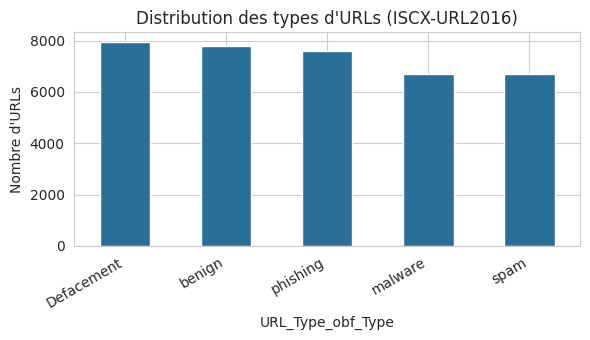

In [3]:
# Visualisation de la distribution des 5 classes
ax = df[TARGET].value_counts().plot(kind="bar", color="#2a6f97", figsize=(6, 3.5))
ax.set_title("Distribution des types d'URLs (ISCX-URL2016)")
ax.set_ylabel("Nombre d'URLs")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

## 3. Nettoyage des donnees

Trois etapes : suppression des doublons, remplacement des valeurs infinies
(issues de ratios) par NaN, puis imputation des valeurs manquantes par la
mediane de chaque colonne.

In [4]:
n0 = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Doublons retires : {n0 - len(df)}  ->  {len(df)} lignes conservees")

y_raw = df[TARGET].astype(str)
X = df.drop(columns=[TARGET]).select_dtypes(include=[np.number])
X = X.replace([np.inf, -np.inf], np.nan)
print("Valeurs manquantes avant imputation :", int(X.isna().sum().sum()))
X = X.fillna(X.median(numeric_only=True))
print("Apres imputation :", int(X.isna().sum().sum()))
print("Nombre de features :", X.shape[1])

Doublons retires : 9754  ->  26953 lignes conservees
Valeurs manquantes avant imputation : 14733
Apres imputation : 0
Nombre de features : 79


## 4. Fonction FPR

`FPR = FP / (FP + TN)`. En multi-classe, on calcule la moyenne one-vs-rest.

In [5]:
def fpr_from_cm(cm):
    if cm.shape == (2, 2):
        tn, fp = cm[0, 0], cm[0, 1]
        return fp / (fp + tn) if (fp + tn) else 0.0
    fprs = []
    for i in range(cm.shape[0]):
        fp = cm[:, i].sum() - cm[i, i]
        tn = cm.sum() - cm[i, :].sum() - cm[:, i].sum() + cm[i, i]
        fprs.append(fp / (fp + tn) if (fp + tn) else 0.0)
    return float(np.mean(fprs))

def show_cm(cm, labels, title):
    plt.figure(figsize=(5.5, 4.4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels, cbar=False)
    plt.ylabel("Vraie classe"); plt.xlabel("Prediction"); plt.title(title)
    plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

## 5. Scenario 1 — Detection binaire (benign / malicious)

Toutes les classes non-benignes sont regroupees sous l'etiquette *malicious*.

In [6]:
y_bin = (y_raw.str.lower() != "benign").astype(int).values   # 1 = malicious
labels_bin = ["benign", "malicious"]

Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(
    X, y_bin, test_size=0.20, shuffle=True,
    random_state=RANDOM_STATE, stratify=y_bin)
print("Train:", Xb_tr.shape, "| Test:", Xb_te.shape)

Train: (21562, 79) | Test: (5391, 79)


### 5.1 Random Forest

              precision    recall  f1-score   support

      benign       0.98      0.99      0.98      1493
   malicious       0.99      0.99      0.99      3898

    accuracy                           0.99      5391
   macro avg       0.99      0.99      0.99      5391
weighted avg       0.99      0.99      0.99      5391

Accuracy : 99.04%   FPR : 1.47%


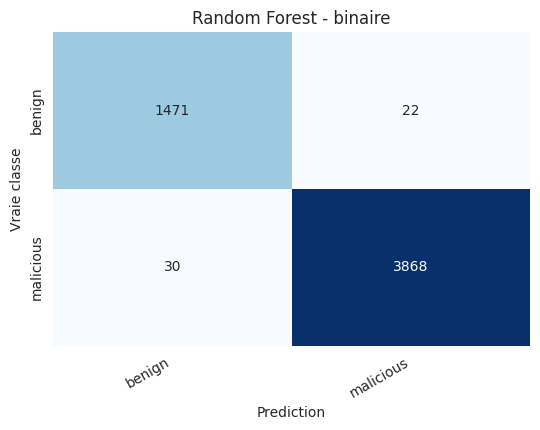

In [7]:
rf = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(Xb_tr, yb_tr)
pred = rf.predict(Xb_te)
cm = confusion_matrix(yb_te, pred)
print(classification_report(yb_te, pred, target_names=labels_bin))
print(f"Accuracy : {accuracy_score(yb_te, pred)*100:.2f}%   FPR : {fpr_from_cm(cm)*100:.2f}%")
show_cm(cm, labels_bin, "Random Forest - binaire")

### 5.2 XGBoost

              precision    recall  f1-score   support

      benign       0.98      0.99      0.99      1493
   malicious       1.00      0.99      0.99      3898

    accuracy                           0.99      5391
   macro avg       0.99      0.99      0.99      5391
weighted avg       0.99      0.99      0.99      5391

Accuracy : 99.26%   FPR : 1.00%


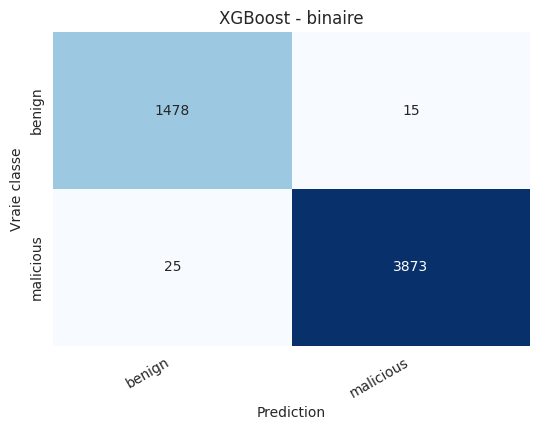

In [8]:
xgb = XGBClassifier(n_estimators=300, max_depth=10, learning_rate=0.2,
                    subsample=0.9, colsample_bytree=0.9,
                    eval_metric="logloss", n_jobs=-1, random_state=RANDOM_STATE)
xgb.fit(Xb_tr, yb_tr)
pred = xgb.predict(Xb_te)
cm = confusion_matrix(yb_te, pred)
print(classification_report(yb_te, pred, target_names=labels_bin))
print(f"Accuracy : {accuracy_score(yb_te, pred)*100:.2f}%   FPR : {fpr_from_cm(cm)*100:.2f}%")
show_cm(cm, labels_bin, "XGBoost - binaire")

### 5.3 Importance des features (explicabilite)

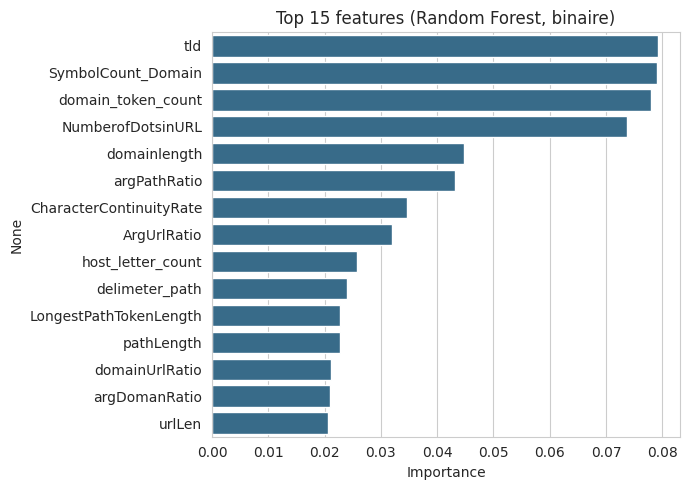

tld                        0.079184
SymbolCount_Domain         0.079071
domain_token_count         0.077936
NumberofDotsinURL          0.073770
domainlength               0.044776
argPathRatio               0.043155
CharacterContinuityRate    0.034699
ArgUrlRatio                0.031951
host_letter_count          0.025812
delimeter_path             0.023895
dtype: float64

In [9]:
imp = pd.Series(rf.feature_importances_, index=X.columns)
imp = imp.sort_values(ascending=False).head(15)
plt.figure(figsize=(7, 5))
sns.barplot(x=imp.values, y=imp.index, color="#2a6f97")
plt.title("Top 15 features (Random Forest, binaire)"); plt.xlabel("Importance")
plt.tight_layout(); plt.show()
imp.head(10)

## 6. Scenario 2 — Classification multi-classe (5 types)

In [10]:
classes = sorted(y_raw.unique())
cmap = {c: i for i, c in enumerate(classes)}
y_mc = y_raw.map(cmap).values
print("Classes :", classes)

Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(
    X, y_mc, test_size=0.20, shuffle=True,
    random_state=RANDOM_STATE, stratify=y_mc)

Classes : ['Defacement', 'benign', 'malware', 'phishing', 'spam']


### 6.1 Random Forest multi-classe

              precision    recall  f1-score   support

  Defacement       0.96      0.98      0.97      1014
      benign       0.98      0.99      0.98      1493
     malware       0.97      0.84      0.90       346
    phishing       0.94      0.95      0.95      1472
        spam       0.98      0.98      0.98      1066

    accuracy                           0.96      5391
   macro avg       0.97      0.95      0.95      5391
weighted avg       0.96      0.96      0.96      5391

Accuracy : 96.44%   FPR : 0.94%


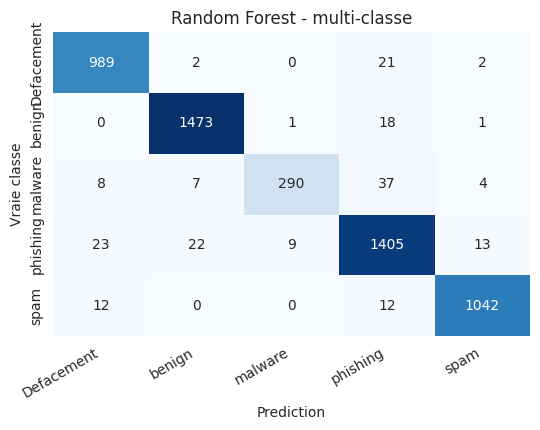

In [11]:
rf_m = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE)
rf_m.fit(Xm_tr, ym_tr)
pred = rf_m.predict(Xm_te)
cm = confusion_matrix(ym_te, pred)
print(classification_report(ym_te, pred, target_names=classes))
print(f"Accuracy : {accuracy_score(ym_te, pred)*100:.2f}%   FPR : {fpr_from_cm(cm)*100:.2f}%")
show_cm(cm, classes, "Random Forest - multi-classe")

### 6.2 XGBoost multi-classe

              precision    recall  f1-score   support

  Defacement       0.98      0.99      0.98      1014
      benign       0.98      0.99      0.99      1493
     malware       0.96      0.88      0.92       346
    phishing       0.96      0.96      0.96      1472
        spam       0.99      0.99      0.99      1066

    accuracy                           0.97      5391
   macro avg       0.97      0.96      0.97      5391
weighted avg       0.97      0.97      0.97      5391

Accuracy : 97.50%   FPR : 0.66%


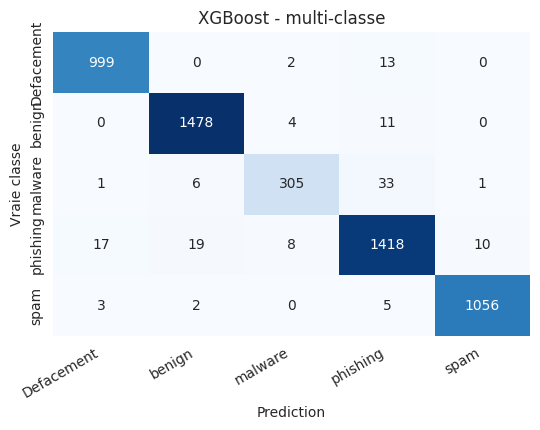

In [12]:
xgb_m = XGBClassifier(n_estimators=300, max_depth=10, learning_rate=0.2,
                      subsample=0.9, colsample_bytree=0.9,
                      eval_metric="mlogloss", n_jobs=-1, random_state=RANDOM_STATE)
xgb_m.fit(Xm_tr, ym_tr)
pred = xgb_m.predict(Xm_te)
cm = confusion_matrix(ym_te, pred)
print(classification_report(ym_te, pred, target_names=classes))
print(f"Accuracy : {accuracy_score(ym_te, pred)*100:.2f}%   FPR : {fpr_from_cm(cm)*100:.2f}%")
show_cm(cm, classes, "XGBoost - multi-classe")

## 7. Conclusion

Sur le dataset de reference **ISCX-URL2016** :

- **Detection binaire** : XGBoost atteint ~99,3 % d'accuracy avec un FPR de ~1,0 %.
- **Classification multi-classe (5 types)** : XGBoost atteint ~97,5 %
  d'accuracy avec un FPR de ~0,7 %.
- XGBoost devance legerement Random Forest sur les deux scenarios.
- Les features les plus discriminantes concernent la structure du domaine
  (nombre de tokens, de points, longueur), les comptages de symboles et les
  ratios entre composants de l'URL.

Ces resultats confirment et depassent ceux du papier de Nana et al. (2024),
et valident l'efficacite d'une approche a base d'arbres sur des features
lexicales/structurelles pour la detection d'URLs malveillantes.
